# Introduction to the Digital Earth Africa Water Quality Monitoring Service (WQMS)

* **Products used:** 
[wq_annual](https://explorer.digitalearth.africa/products/wq_annual)

## Background
This notebook is part of a collection of water quality (WQ) analysis notebooks that use Earth observation data to assess surface water conditions. 
Combined, these notebooks provide a more holistic view of water quality by enabling analysis across multiple indicators.

This notebook introduces the several variables available in the _annual_ water quality product. 
Workflows are provided to monitor these variables on shorter time scales, such as for [turbidity](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks/blob/main/Real_world_examples/Water_quality_monthly_monitoring_turbidity.ipynb) and [Floating Algae Index](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks/blob/main/Real_world_examples/Water_quality_FAI_monitoring.ipynb).

The Water Quality Monitoring Service (WQMS) delivers water quality information for surface water bodies across the African continent. 
Earth Observation (EO) data provides continuous spatial coverage and change monitoring at a fraction of the cost and logistical complexity of in-situ monitoring. 
As national governments across Africa work to address Sub-indicator 2 of [Sustainable Development Goal (SDG) 6.6.1](https://www.unwater.org/our-work/sdg-6-integrated-monitoring-initiative/indicator-661-change-extent-water-related) — Water Quality of Lakes and Artificial Water Bodies — the Water Quality Monitoring System (WQMS) will provide timely, decision-relevant information to support the management and sustainable use of surface water resources. 
This includes indicators such as the overall water turbidity, and the Trophic State Index, which serves as a proxy for the biological health of a water body.

## Description
This notebook demonstrates how to load the annual DE Africa Water Quality data using the [Open Data Cube](https://opendatacube.readthedocs.io/en/latest/about-core-concepts/index.html) software. 
Topics covered include:

1. [Load and inspect annual water quality data](#Load-and-inspect-annual-water-quality-data)
2. [Yearly change monitoring](#Yearly-change-monitoring)
3. [Animation over time](#Animation-over-time)
4. [Water Quality Summaries](#Water-quality-summaries)

<div class="alert alert-info">
    
**Note:** Visit the [DE Africa Water Quality User Guide](https://docs.digitalearthafrica.org/en/latest/data_specs/Water_Quality_specs.html) for detailed technical information including methods, quality, and data access.

</div>

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec
import cmocean  # For nice ocean colour maps
from deafrica_tools.plotting import display_map, xr_animation
from deafrica_tools.waterbodies import get_waterbody, get_water_quality_summary, get_water_quality_rankings
from IPython.core.display import Video

In [2]:
# additional capabilities 


### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [3]:
dc = datacube.Datacube(app="DE_Africa_Water_Quality_Monitoring_Service")

## Load and inspect annual water quality data

Define the location (lat/lon range) and time period to extract water quality data. 
The default location is Lake Ichkeul in northern Tunisia. 

We explicitly define the list of water quality layers to load.

In [4]:
query = {
    "product": "wq_annual",
    "x": (9.56, 9.77),
    "y": (37.11, 37.21),
    "crs": "EPSG:4326",
    "time": ("2000-01-01", "2025-12-31"),
    "output_crs": "EPSG:6933",
    "resolution": (-10, 10),
    "measurements": [
        "tsm",  # Turbidity
        "chla",  # Chlorophyll-A
        "tsi",  # Trophic State Index
        "agm_ndvi",  # NDVI
        "agm_hue",  # Water Hue
        "agm_owt",  # Optical Water Type
        "agm_fai",  # Floating Algal Index
        "clear_water",  # Clear water mask
        "water_mask",  # Water presence mask
        "tirs_st_ann_max",  # Max water surface temperature
        "tirs_st_ann_med",  # Median water surface temperature
        "tirs_st_ann_min",  # Min water surface temperature
    ],
}

In [8]:
display_map(x=query["x"], y=query["y"])

In [9]:
ds = dc.load(**query)

In [10]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:          (time: 26, y: 1022, x: 2028)
Coordinates:
  * time             (time) datetime64[ns] 208B 2000-07-01T23:59:59.999999 .....
  * y                (y) float64 8kB 4.428e+06 4.427e+06 ... 4.417e+06 4.417e+06
  * x                (x) float64 16kB 9.224e+05 9.224e+05 ... 9.427e+05
    spatial_ref      int32 4B 6933
Data variables:
    tsm              (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    chla             (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tsi              (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_ndvi         (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_hue          (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_owt          (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    agm_fai          (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    clear_water      (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    water_mask       (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tirs_st_ann_max  (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tirs_st_ann_med  (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
    tirs_st_ann_min  (time, y, x) float32 216MB nan nan nan nan ... nan nan nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

### Water Masks
As can be seen above, there are several variables available. 
Below, we plot the water presence mask, generated from the WOfS product over a rolling 5-year period (since floating vegetation can dominate the water surface for long periods of time).

> For the first few water quality layers below, we will visualise maps from 2005 and 2025. Different years can be selected for different water bodies.

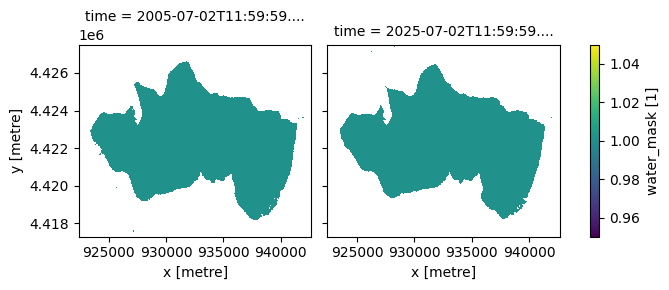

In [11]:
ds.sel(time=ds.time.dt.year.isin([2005, 2025])).water_mask.plot(col="time");

### Floating Algae Index (FAI)
The Floating Algae Index is used to detect and monitor floating vegetation and algal blooms, which are often problematic or hazardous. 
FAI supports early warning and risk management. 
Areas of algae and surface vegetation must also be mapped before applying algorithms for Chlorophyll-A or turbidity. 
The FAI is only provided when it is above a threshold of 0.05, i.e., when there's a likely presence of floating algae.

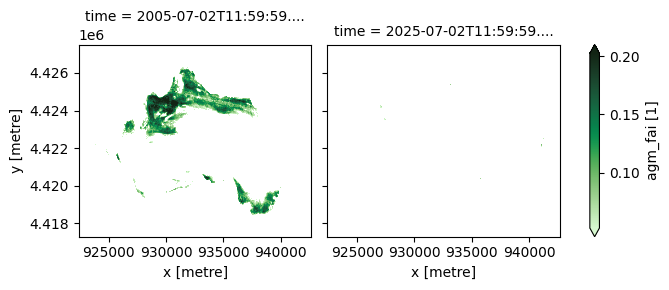

In [12]:
ds.agm_fai.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(
    robust=True, col="time", cmap="cmo.algae"
);

### Clear Water Mask
The clear water mask is defined as areas where water is detected and the FAI is below the 0.05 threshold. 
Subsequent layers—including optical water type, hue, total suspended matter, chlorophyll‑a, and the trophic state index—contain values only within the `clear_water` mask.

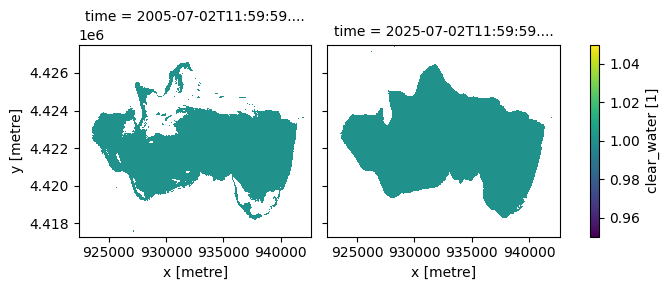

In [13]:
ds.clear_water.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(col="time");

### Total Suspended Matter (TSM)
The annual Total Suspended Matter (TSM) is provided as an indicator on a *relative* scale, with values designed to correspond to $\mathrm{mg}/\mathrm{m^3}$ of suspended particles. 
TSM values are related to the turbidity or the cloudiness of water. 
Higher TSM values can clog water habitats and reduce ecosystem productivity and oxygen generation.

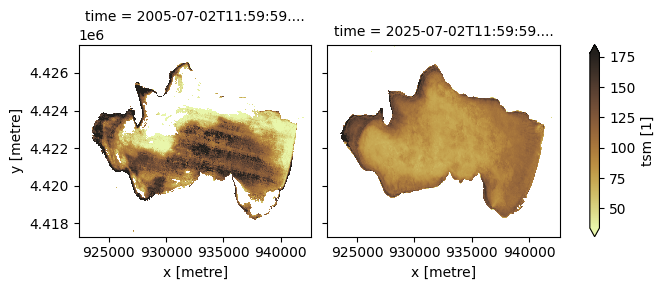

In [14]:
ds.tsm.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(
    robust=True, col="time", cmap="cmo.turbid"
);

### Chlorophyll-A (ChlA)
Chlorophyll-A is an indicator of algal content, used to identify conditions conducive to algal blooms and assess biological productivity. 
ChlA is provided as an indicator on a *relative* scale, with values designed to correspond to $\mathrm{mg}/\mathrm{m^3}$. 
ChlA is readily transformed to the Trophic State Index used in SDG reporting, as is done in the next cell.

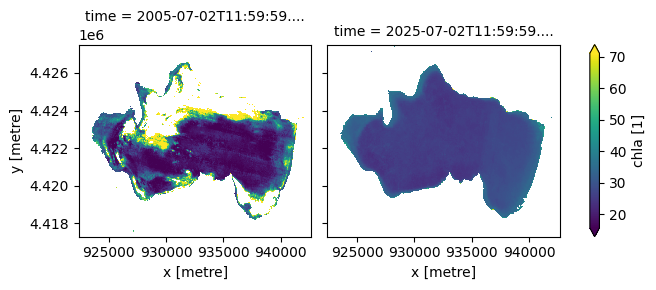

In [15]:
ds.chla.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(robust=True, col="time");

### Trophic State Index (TSI)
Derived from chlorophyll-a, the TSI provides an indicator of lake trophic status and productivity. 
Values typically range from 0 to 100, with higher values reflecting greater algal biomass and increasing eutrophication. 
In this product, the TSI is calculated as a logarithmic function of chlorophyll-a concentration, following [Carlson 1977](https://doi.org/10.4319%2Flo.1977.22.2.0361), with a continuous relationship fitted to the published ChlA–TSI class relationships to estimate TSI directly rather than using discrete class bins.

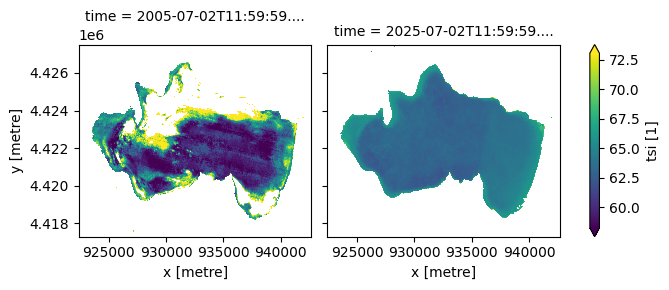

In [16]:
ds.tsi.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(robust=True, col="time");

### Hue
The water colour, also known as the hue of the water, derived from the spectral reflectances measured by the EO instruments. 
Hue is expressed as an angle from 0-360. 
The hue of the waterbody is an objective way to determine changes in water colour.

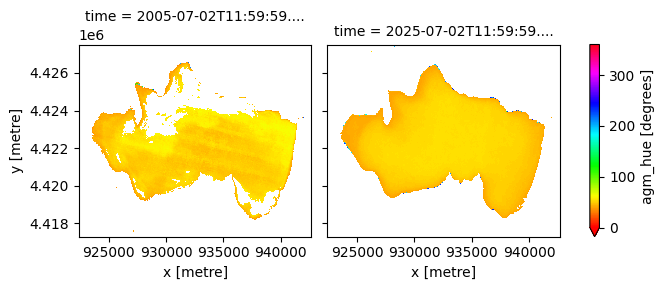

In [17]:
ds.agm_hue.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(
    robust=True, col="time", cmap="hsv", vmin=0, vmax=360
);

### Optical Water Type (OWT)
OWT [(Spyrakos et al., 2018)](https://doi.org/10.1002/lno.10674) is a classification of water types used to support EO based monitoring of water quality. 
For inland waters 13 OWTs are identified based on their spectral characteristics. 
These can then be characterised as oligotrophic, eutrophic, or hypereutrophic water types. 
The OWT of a waterbody may change seasonally or over the longer term.

| OWT   | Class                          | Dominant Characteristics                                                                 |
|-------|--------------------------------|-----------------------------------------------------------------------------------------|
| OWT1  | eutrophic_and_blue_green        | Hypereutrophic waters with scum of cyanobacterial bloom and vegetation-like Rrs         |
| OWT2  | eutrophic_and_blue_green        | Common case waters with diverse reflectance shape and marginal dominance of pigments and Colored Dissolved Organic Matter (CDOM) over inorganic suspended particles |
| OWT3  | oligotrophic_clear              | Clear waters                                                                            |
| OWT4  | eutrophic_and_blue_green        | Turbid waters with high organic content                                                 |
| OWT5  | eutrophic_and_blue_green        | Sediment-laden waters                                                                   |
| OWT6  | hyper_eutrophic_green_brown     | Balanced effects of optically active constituents at shorter wavelengths               |
| OWT7  | hyper_eutrophic_green_brown     | Highly productive waters with high cyanobacteria abundance and elevated reflectance at red/near-infrared spectral region |
| OWT8  | hyper_eutrophic_green_brown     | Productive waters with cyanobacteria presence and with remote sensing reflectance (Rrs) peak close to 700 nm        |
| OWT9  | oligotrophic_clear              | Optically neighboring to OWT2 waters but with higher Rrs at shorter wavelengths        |
| OWT10 | hyper_eutrophic_green_brown     | CDOM-rich waters                                                                         |
| OWT11 | eutrophic_and_blue_green        | Waters high in CDOM with cyanobacteria presence and high absorption efficiency by Non-Algal Particles (NAP)  |
| OWT12 | eutrophic_and_blue_green        | Turbid, moderately productive waters with cyanobacteria presence                        |
| OWT13 | oligotrophic_clear              | Very clear blue waters                                                                  |

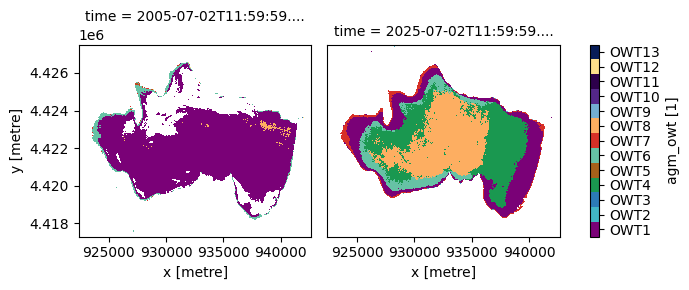

In [18]:
# Same colours as DE Africa Maps
colors = [
    "#7A0177",
    "#41B6C4",
    "#2C7BB6",
    "#1A9850",
    "#A6611A",
    "#66C2A5",
    "#D73027",
    "#FDAE61",
    "#74ADD1",
    "#542788",
    "#2D004B",
    "#FEE08B",
    "#081D58",
]

levels = np.arange(1, 14)
bounds = np.arange(0.5, 14.5, 1)
labels = [f"OWT{i}" for i in levels]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

im = ds.agm_owt.sel(time=ds.time.dt.year.isin([2005, 2025])).plot(
    cmap=cmap, norm=norm, col="time", add_colorbar=True
)

cbar = im.cbar
cbar.set_ticks(levels)
cbar.set_ticklabels(labels)

# Remove extra ticks at class boundaries
cbar.ax.minorticks_off()

# Share y axis ticks and labels
im.axs.flat[-1].tick_params(left=False, labelleft=False)
        
plt.show()

### Water Temperature 
The surface water temperature, derived from the Thermal Infrared Sensor (TIRS) onboard Landsat-8 and Landsat-9, is a key variable influencing biological activity, stratification, and ecosystem dynamics.
For each pixel, the 10th, 50th, and 90th percentiles of surface temperature measured in a year are recorded as the minimum, median, and maximum values.
Below, we plot the surface temperature measurements for 2024.

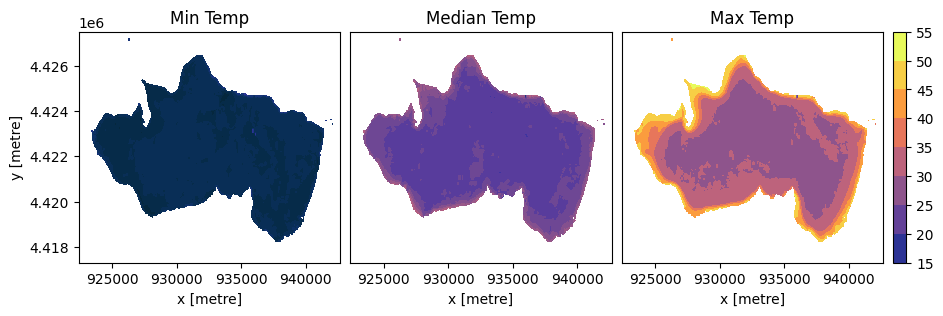

In [19]:
# Temperature variables to plot
temp_vars = ["tirs_st_ann_min", "tirs_st_ann_med", "tirs_st_ann_max"]
titles = ["Min Temp", "Median Temp", "Max Temp"]

# Shared min and max for colourbar
vmin = min(ds[v].sel(time="2024").min().item() for v in temp_vars)
vmax = max(ds[v].sel(time="2024").max().item() for v in temp_vars)

# Calculate figure size based on previous plot to preserve proportions
figsize_facetgrid = im.fig.get_size_inches()
panel_width = figsize_facetgrid[0] / len(im.axs.flat)
panel_height = figsize_facetgrid[1]

# Account for three plots and a colourbar
plot_ratios = [1, 1, 1]
colorbar_ratio = 0.05
total_ratio = sum(plot_ratios) + colorbar_ratio

figsize = (
    panel_width * total_ratio,
    panel_height
)

fig = plt.figure(figsize=figsize)

gs = GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.05],
    wspace=0.05
)

axs = [fig.add_subplot(gs[i]) for i in range(3)]
cax = fig.add_subplot(gs[3])

for ax, var, title in zip(axs, temp_vars, titles):
    im_temp = ds[var].sel(time="2024").squeeze().plot.contourf(
        ax=ax,
        cmap="cmo.thermal",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title)

# Remove ylabel and yticks for 2nd and 3rd plot
for i, ax in enumerate(axs):
    
    if i > 0:
        ax.set_ylabel("")
        ax.set_yticks([])

# Shared colorbar
fig.colorbar(im_temp, cax=cax)

plt.show()

## Yearly change monitoring

The annual water quality maps can be used to track year-to-year trends in water quality. 
We plot the spatial median of each yearly timestep as a time series. 
We also plot the interquartile ranges, demonstrating a simple method for anomaly detection.

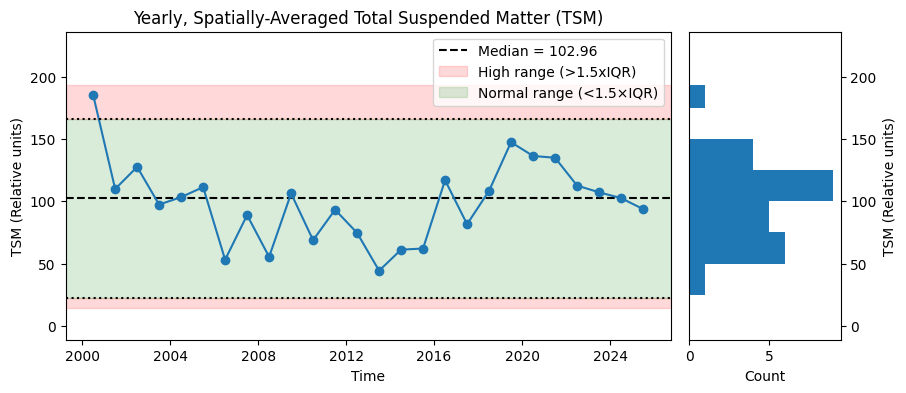

In [20]:
# Spatially-averaged time series
ts = ds.median(dim=["x", "y"])
vals = ts["tsm"].values

# Median
median_value = np.nanmedian(vals)

# IQR anomaly thresholds
q1 = np.nanpercentile(vals, 25)
q3 = np.nanpercentile(vals, 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Figure layout
fig = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

ax = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax)

# Plot median of medians
ax.axhline(
    median_value, color="black", linestyle="--", label=f"Median = {median_value:.2f}"
)

# Plot time series
ts["tsm"].plot.line(ax=ax, marker="o")

# Plot IQR bounds
ax.axhline(lower_bound, color="black", linestyle=":")
ax.axhline(upper_bound, color="black", linestyle=":")

# Shade anomaly regions
ymin, ymax = ax.get_ylim()
ax.axhspan(ymin, lower_bound, color="red", alpha=0.15, label = "High range (>1.5xIQR)")
ax.axhspan(upper_bound, ymax, color="red", alpha=0.15)

# Shade normal region
ax.axhspan(
    lower_bound, upper_bound, color="green", alpha=0.15, label="Normal range (<1.5×IQR)"
)

# Labels
ax.set_title("Yearly, Spatially-Averaged Total Suspended Matter (TSM)")
ax.set_xlabel("Time")
ax.set_ylabel("TSM (Relative units)")
ax.legend()

# Align histogram bins to yticks
yticks = np.unique(ax.get_yticks())  # Remove duplicates
bins = np.sort(np.concatenate(([ymin], yticks, [ymax])))  # Ensure monotonic

ax_hist.hist(vals, bins=bins, orientation="horizontal")

# Histogram labels
ax_hist.set_xlabel("Count")
ax_hist.set_ylabel("TSM (Relative units)")
ax_hist.yaxis.set_label_position("right")
ax_hist.yaxis.tick_right()

plt.show()

## Animation over time

The annual maps can be visualised in an animation as demonstrated below using the `xr_animation` function. 
The `interval` parameter specifies the time in milliseconds between each image in the animation.

In [21]:
# Calculate inverse scaling of data shape to remove spatial distortion 
ny, nx = ds.tsm.isel(time=0).shape
inverse_data_aspect = nx / ny

xr_animation(
    ds,
    bands="tsm",
    output_path="water_quality.mp4",
    interval=500,
    show_date="%Y",
    annotation_kwargs={"fontsize": 28},
    imshow_kwargs={"cmap": "cmo.turbid", "aspect": inverse_data_aspect},
    colorbar_kwargs={"labelcolor": "black"}
)

plt.close()
Video(f"water_quality.mp4", embed=True)

Exporting animation to water_quality.mp4


  0%|          | 0/26 (0.0 seconds remaining at ? frames/s)

## Water Quality Summaries

Together with the annual variables, the Water Quality Monitoring Service also provides per waterbody annual variable summaries for the over 700,000 waterbodies across the continent identified in the Waterbodies Service. 
The cell below demonstrates how to load the water quality summary for a waterbody.

For the NDVI and FAI variables, the summaries provided are `ndvi_cover` and `fai_cover` respectively.
The `ndvi_cover` indicates the percentage of the waterbody that showed persistent vegetation cover throughout the year. 
The `fai_cover` indicates the percentage of the waterbody that showed persistent algal bloom cover throughout the year.

For the remaining variables i.e. hue (`hue`), optical water type (`owt`), median temperature (`st_median`), maximum temperature (`st_max`), minimum temperature (`st_min`), chlorophyll-a (`chla`), turbidity (`tsm`) and trophic state (`ts`), the value for each 10th percentile increment of a variable for a waterbody is provided.

The identifier for the waterbody can be found by loading the Waterbodies product in DE Africa Maps and clicking on the waterbody. 
Here is an example for Lake Ichkeul: https://maps.digitalearth.africa/#share=s-gVaEjpEAOcjPcUjX7N3oOxVBXnx

In [21]:
# Waterbody uid for Lake Ichkeul
waterbody_uid = "snwg7u50bd"
waterbody = get_waterbody(waterbody_uid)
waterbody.explore()

In [31]:
# Waterbody uid for Lake Natron
waterbody_uid = "kz9de3xqry"
waterbody = get_waterbody(waterbody_uid)
waterbody.explore()
# Waterbody uid for SA Small dam
waterbody_uid = "k3vzewssef"
waterbody = get_waterbody(waterbody_uid)
waterbody.explore()
# Waterbody uid for Morocco dam
waterbody_uid = "ey50z40vwz"
waterbody = get_waterbody(waterbody_uid)
waterbody.explore()

In [32]:
wq_summary = get_water_quality_summary(waterbody_uid, start_date="2000-01-01", end_date="2025-12-31")
wq_summary.head()

,hue_q0_1,hue_q0_2,hue_q0_3,hue_q0_4,hue_q0_5,hue_q0_6,hue_q0_7,hue_q0_8,hue_q0_9,owt_q0_1,...,st_min_q0_2,st_min_q0_3,st_min_q0_4,st_min_q0_5,st_min_q0_6,st_min_q0_7,st_min_q0_8,st_min_q0_9,fai_cover,ndvi_cover
date,,,,,,,,,,,,,,,,,,,,,
2000-07-01,46.191898,53.904838,60.491930,65.607098,68.406708,69.961191,71.368495,73.313374,75.573807,3.0,...,13.719648,13.872849,13.983364,14.082483,14.300795,14.654612,15.140004,15.901538,1.046361,6.566737
2001-07-02,45.910009,55.049436,60.537769,64.185674,65.951466,67.183122,68.498940,70.517647,73.203550,3.0,...,14.327667,14.471829,14.599737,14.716632,14.865656,15.054555,15.328451,15.781007,0.006275,1.513725
2002-07-02,42.281571,46.443917,49.823180,51.371427,52.473656,53.625961,54.964004,56.426826,58.255337,1.0,...,15.782064,15.906063,16.022774,16.148108,16.295309,16.512316,16.805043,17.361176,0.000958,0.229016
2003-07-02,48.103025,54.083081,58.294705,60.150389,61.626764,62.882199,64.202194,65.667290,67.408105,1.0,...,13.866872,14.047926,14.181378,14.282094,14.390330,14.503089,14.623132,14.853264,0.022359,0.992845
2004-07-01,48.611924,55.599960,59.714956,61.751277,63.009361,64.210539,65.655487,67.598422,69.968201,1.0,...,14.662287,14.819399,14.967360,15.114712,15.305176,15.537972,15.791937,16.140589,0.053070,1.964073


In [24]:
wq_summary.columns

Index(['hue_q0_1', 'hue_q0_2', 'hue_q0_3', 'hue_q0_4', 'hue_q0_5', 'hue_q0_6',
       'hue_q0_7', 'hue_q0_8', 'hue_q0_9', 'owt_q0_1', 'owt_q0_2', 'owt_q0_3',
       'owt_q0_4', 'owt_q0_5', 'owt_q0_6', 'owt_q0_7', 'owt_q0_8', 'owt_q0_9',
       'chla_q0_1', 'chla_q0_2', 'chla_q0_3', 'chla_q0_4', 'chla_q0_5',
       'chla_q0_6', 'chla_q0_7', 'chla_q0_8', 'chla_q0_9', 'tsi_q0_1',
       'tsi_q0_2', 'tsi_q0_3', 'tsi_q0_4', 'tsi_q0_5', 'tsi_q0_6', 'tsi_q0_7',
       'tsi_q0_8', 'tsi_q0_9', 'tsm_q0_1', 'tsm_q0_2', 'tsm_q0_3', 'tsm_q0_4',
       'tsm_q0_5', 'tsm_q0_6', 'tsm_q0_7', 'tsm_q0_8', 'tsm_q0_9',
       'st_max_q0_1', 'st_max_q0_2', 'st_max_q0_3', 'st_max_q0_4',
       'st_max_q0_5', 'st_max_q0_6', 'st_max_q0_7', 'st_max_q0_8',
       'st_max_q0_9', 'st_median_q0_1', 'st_median_q0_2', 'st_median_q0_3',
       'st_median_q0_4', 'st_median_q0_5', 'st_median_q0_6', 'st_median_q0_7',
       'st_median_q0_8', 'st_median_q0_9', 'st_min_q0_1', 'st_min_q0_2',
       'st_min_q0_3', 'st_min_q0_

In [8]:
# Same colours as DE Africa Maps
colors = [
    "#7A0177",
    "#41B6C4",
    "#2C7BB6",
    "#1A9850",
    "#A6611A",
    "#66C2A5",
    "#D73027",
    "#FDAE61",
    "#74ADD1",
    "#542788",
    "#2D004B",
    "#FEE08B",
    "#081D58",
]

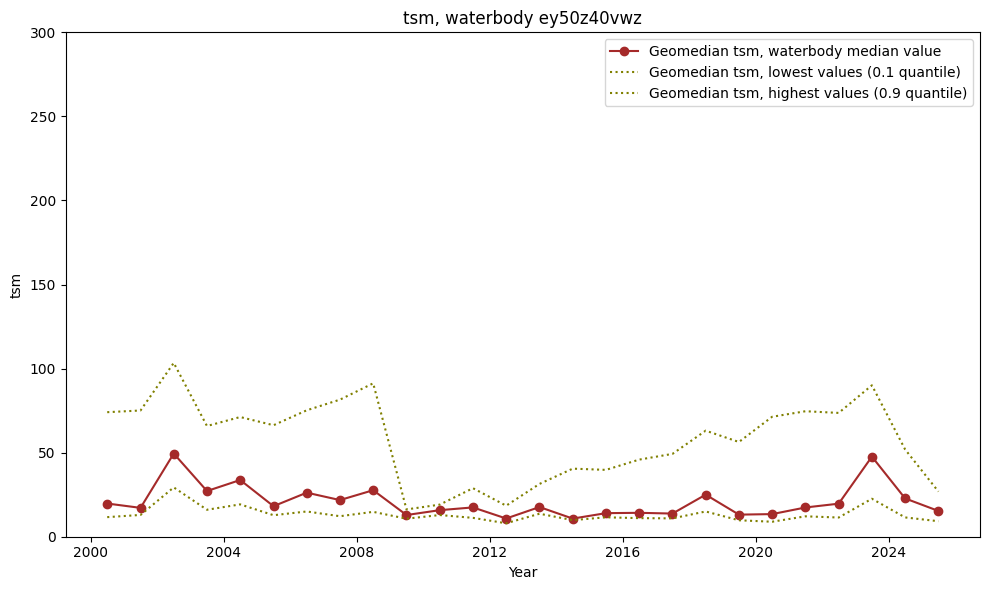

In [33]:
variables = list(['tsm'])
var = variables[0]
q = '_q0_5'
fig, axes = plt.subplots(figsize=(10, 6))
axis = axes
axis.plot(wq_summary.index, wq_summary[var+q], color="brown", linestyle="-", marker="o", label=f"Geomedian {var}, waterbody median value")
axis.plot(wq_summary.index, wq_summary[var+'_q0_1'], color="olive", linestyle=":", marker="", label=f"Geomedian {var}, lowest values (0.1 quantile)")
axis.plot(wq_summary.index, wq_summary[var+'_q0_9'], color="olive", linestyle=":", marker="", label=f"Geomedian {var}, highest values (0.9 quantile)")
axis.set_xlabel("Year")
axis.set_ylim(0, 300)
axis.set_ylabel(var)
axis.set_title(f"{var}, waterbody {waterbody_uid}")
axis.legend()
plt.tight_layout()
plt.show()

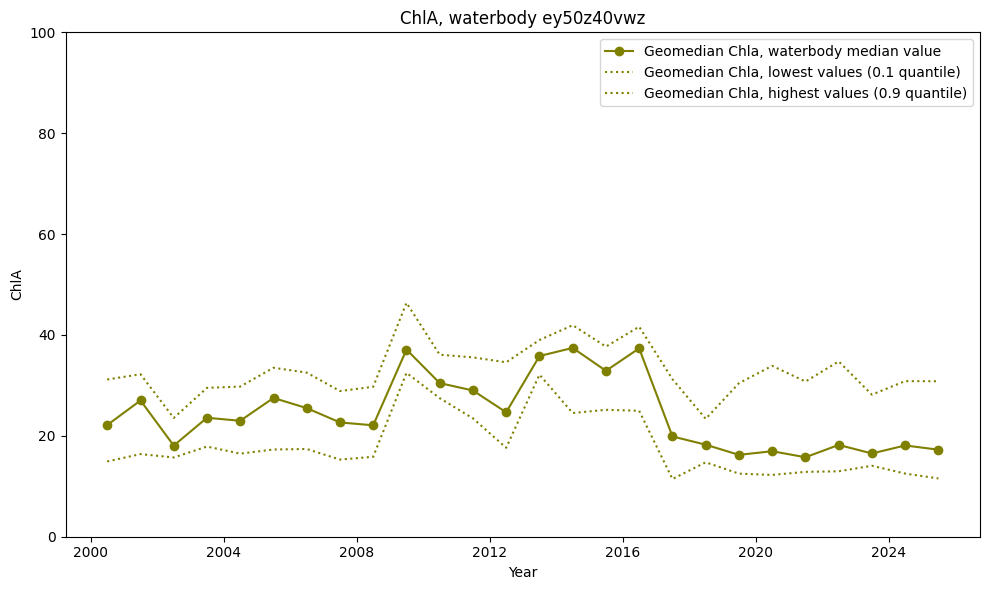

In [34]:
variables = list(['chla'])
var = variables[0]
q = '_q0_5'
fig, axes = plt.subplots(figsize=(10, 6))
axis = axes
axis.plot(wq_summary.index, wq_summary[var+q], color="olive", linestyle="-", marker="o", label="Geomedian Chla, waterbody median value")
axis.plot(wq_summary.index, wq_summary[var+'_q0_1'], color="olive", linestyle=":", marker="", label="Geomedian Chla, lowest values (0.1 quantile)")
axis.plot(wq_summary.index, wq_summary[var+'_q0_9'], color="olive", linestyle=":", marker="", label="Geomedian Chla, highest values (0.9 quantile)")
axis.set_xlabel("Year")
axis.set_ylim(0, 100)
axis.set_ylabel("ChlA")
axis.set_title(f"ChlA, waterbody {waterbody_uid}")
axis.legend()
plt.tight_layout()
plt.show()

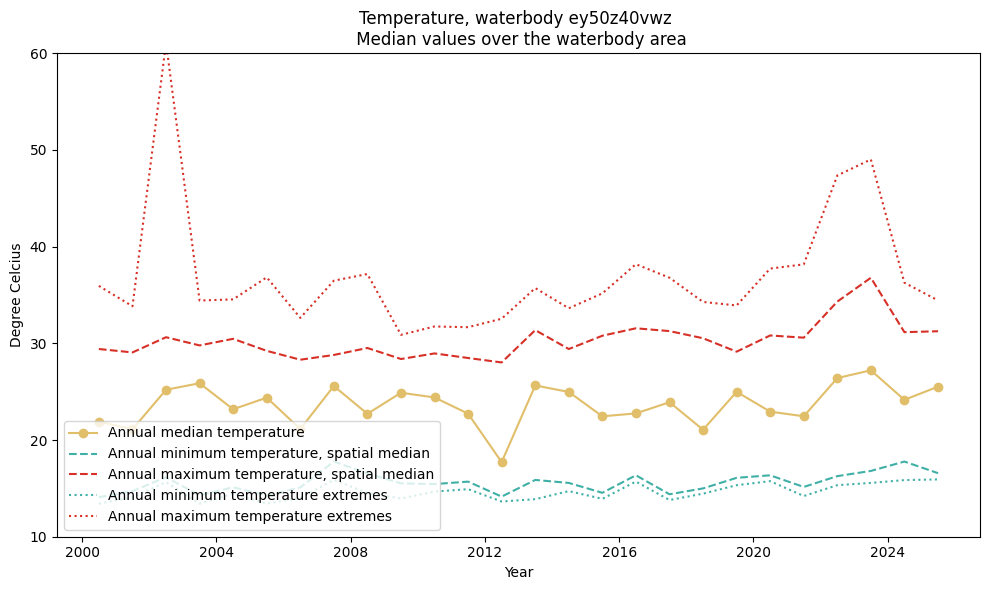

In [35]:
variables = list(('st_max','st_min','st_median'))
var = variables[2]
q = '_q0_5'
fig, axes = plt.subplots(figsize=(10, 6))
axis = axes
axis.plot(wq_summary.index, wq_summary[var+q], color="#E1BE6A", linestyle="-", marker="o", label="Annual median temperature")
axis.plot(wq_summary.index, wq_summary['st_min'+q], color="#40B0A6", linestyle="--", marker="", label="Annual minimum temperature, spatial median")
axis.plot(wq_summary.index, wq_summary['st_max'+q], color=colors[6], linestyle="--", marker="", label="Annual maximum temperature, spatial median")
axis.plot(wq_summary.index, wq_summary['st_min'+'_q0_1'], color="#40B0A6", linestyle=":", marker="", label="Annual minimum temperature extremes")
axis.plot(wq_summary.index, wq_summary['st_max'+'_q0_9'], color=colors[6], linestyle=":", marker="", label="Annual maximum temperature extremes")
axis.set_xlabel("Year")
axis.set_ylim(10, 60)
axis.set_ylabel("Degree Celcius")
axis.set_title(f"Temperature, waterbody {waterbody_uid} \n Median values over the waterbody area")
axis.legend(loc='lower left')
plt.tight_layout()
plt.show()

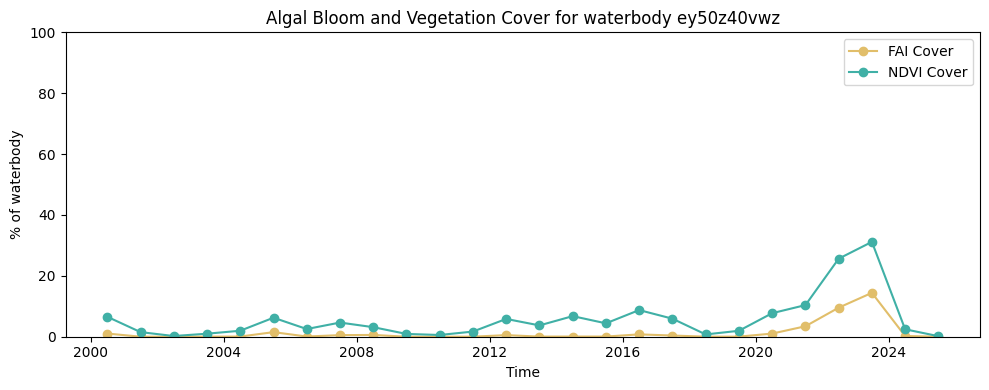

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wq_summary.index, wq_summary["fai_cover"], color="#E1BE6A", linestyle="-", marker="o", label="FAI Cover")
ax.plot(wq_summary.index, wq_summary["ndvi_cover"], color="#40B0A6", linestyle="-", marker="o", label="NDVI Cover")
ax.set_xlabel("Time")
ax.set_ylim(0, 100)
ax.set_ylabel("% of waterbody")
ax.set_title(f"Algal Bloom and Vegetation Cover for waterbody {waterbody_uid}")
ax.legend()
plt.tight_layout()
plt.show()

The Water Quality Monitoring Service also provides a ranking for each waterbody compared to all other waterbodies in the Waterbodies Service. 
The service averages the water quality summary metrics: `fai_cover`, `ndvi_cover`, `hue_q0_5`, `owt_q0_5`, `chla_q0_5`, `tsi_q0_5`, `tsm_q0_5`, `st_max_q0_5`, `st_median_q0_5` and `st_min_q0_5` over the period 2020 – 2025 and provides a percentile ranking for each waterbody.

As can be seen below, Lake Ichkeul ranks highly for Total Suspended Matter (TSM) compared to other African waterbodies.

In [37]:
wq_rank = get_water_quality_rankings(waterbody_uid)


In [38]:
wq_rank.loc[0,:]

fai_cover_percentile          14.0
 ndvi_cover_percentile         6.0
 hue_q0_5_percentile          75.0
 owt_q0_5_percentile          51.0
 chla_q0_5_percentile          1.0
 tsi_q0_5_percentile           1.0
 tsm_q0_5_percentile          36.0
 st_max_q0_5_percentile       30.0
 st_median_q0_5_percentile    16.0
 st_min_q0_5_percentile       16.0
Name: 0, dtype: float64

In [58]:
wq_rank.loc[0," tsm_q0_5_percentile"]

np.float64(94.0)

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [27]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [28]:
from datetime import datetime

datetime.today().strftime("%Y-%m-%d")

'2026-03-24'